This is a numerical implementation of the Lotka-Volterra equations, an ODE model.

The Lotka-Volterra equations are:

dX/dt = αX - βXY

dY/dt = δXY - γY

X = prey population,
Y = predator population,
α = prey growth rate,
β = predation rate,
γ = predator death rate,
δ = predator reproduction efficiency (from consuming prey),

In [ ]:
# Imports
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

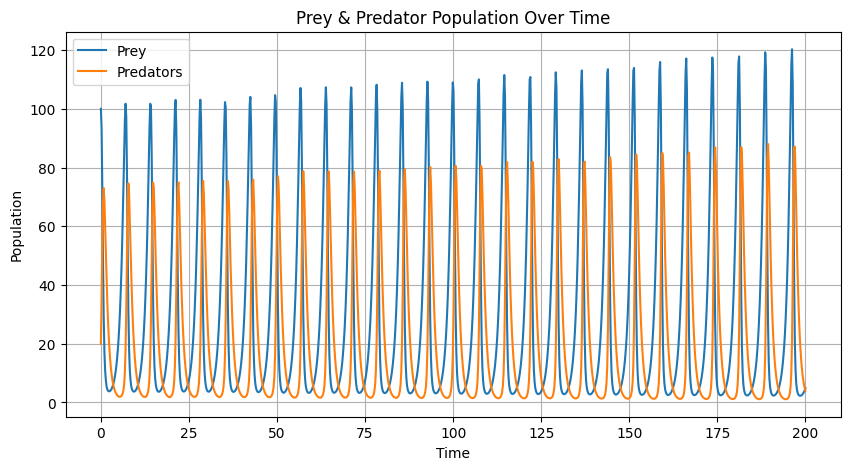

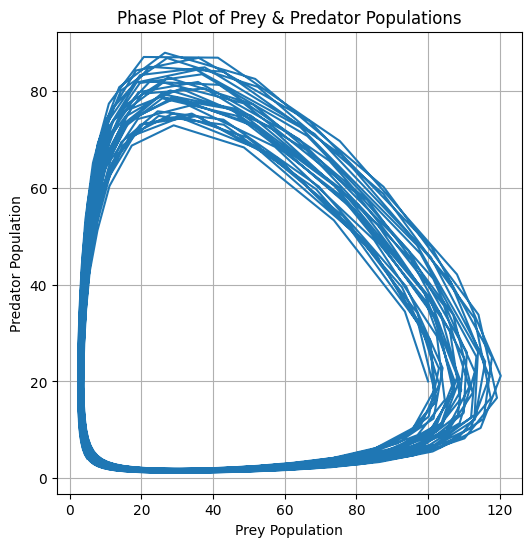

In [ ]:
# Lotka-Volterra function definition
def lotka_volterra(t, z, alpha, beta, gamma, delta):
  X, Y = z
  dXdt = (alpha * X) - (beta * X * Y)
  dYdt = (delta * X * Y) - (gamma * Y)
  return [dXdt, dYdt]

# Parameters
alpha = 1.0   # Prey growth
beta = 0.05   # Predation rate
gamma = 1.2   # Predator death
delta = 0.04  # Predator growth

# Initial populations
X_0 = 100
Y_0 = 20
z_0 = [X_0, Y_0]

# Time span
t_start = 0
t_end = 200
t_eval = np.linspace(t_start, t_end, 1000)

# Solve
sol = solve_ivp(lotka_volterra,
                [t_start, t_end],
                z_0,
                args=(alpha, beta, gamma, delta),
                t_eval=t_eval)

# Extract solution
t = sol.t
X = sol.y[0]
Y = sol.y[1]

# Populations vs time plot
plt.figure(figsize=(10, 5))
plt.plot(t, X, label="Prey")
plt.plot(t, Y, label="Predators")
plt.xlabel("Time")
plt.ylabel("Population")
plt.title("Prey & Predator Population Over Time")
plt.legend()
plt.grid(True)
plt.show()

# Phase plot
plt.figure(figsize=(6, 6))
plt.plot(X, Y)
plt.xlabel("Prey Population")
plt.ylabel("Predator Population")
plt.title("Phase Plot of Prey & Predator Populations")
plt.grid(True)
plt.show()


Now a slightly more advanced and realistic model:

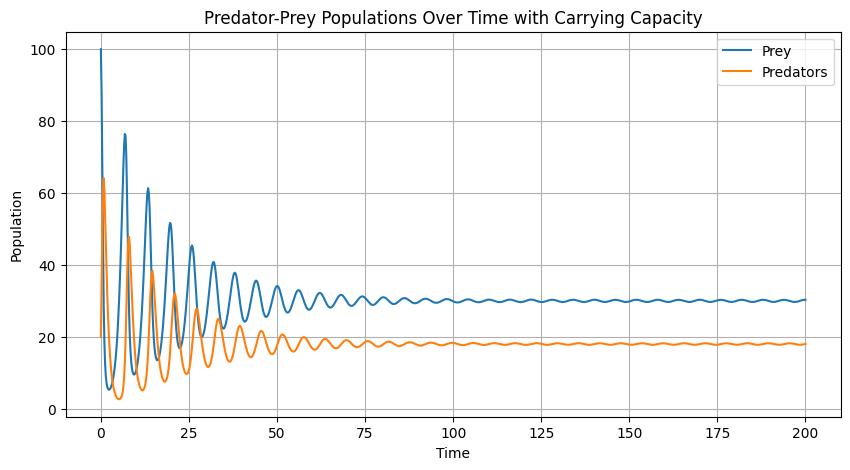

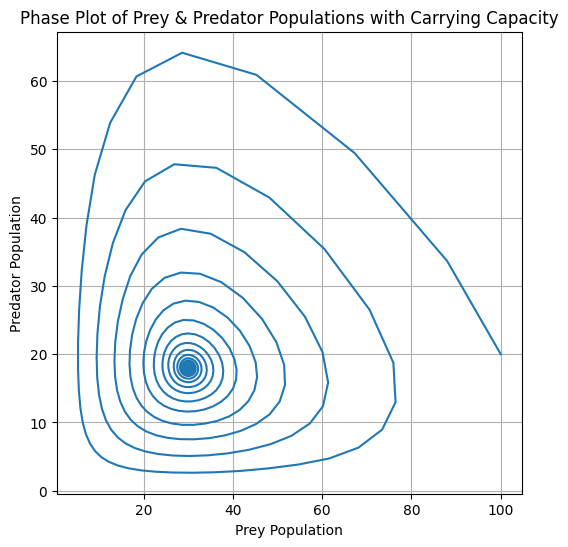

In [ ]:
# Improved ODE Model
def predator_prey_logistic(t, z, alpha, beta, gamma, delta, K):
  X, Y = z
  dXdt = (alpha * X * (1 - (X / K))) - (beta * X * Y)
  dYdt = (delta * X * Y) - (gamma * Y)
  return [dXdt, dYdt]

# Parameters
alpha = 1.0   # Prey growth
beta = 0.05   # Predation rate
gamma = 1.2   # Predator death
delta = 0.04  # Predator growth
K = 300       # Carrying capacity

# Initial conditions
X_0 = 100
Y_0 = 20
z_0 = [X_0, Y_0]

# Time settings
t_start = 0
t_end = 200
t_eval = np.linspace(t_start, t_end, 1000)

# Solve
sol = solve_ivp(predator_prey_logistic,
                [0, 200],
                z_0,
                args=(alpha, beta, gamma, delta, K),
                t_eval=t_eval)

# Results
t = sol.t
X = sol.y[0]
Y = sol.y[1]

# Populations vs time plot
plt.figure(figsize=(10, 5))
plt.plot(t, X, label="Prey")
plt.plot(t, Y, label="Predators")
plt.xlabel("Time")
plt.ylabel("Population")
plt.title("Predator-Prey Populations Over Time with Carrying Capacity")
plt.legend()
plt.grid(True)
plt.show()

# Phase plot
plt.figure(figsize=(6, 6))
plt.plot(X, Y)
plt.xlabel("Prey Population")
plt.ylabel("Predator Population")
plt.title("Phase Plot of Prey & Predator Populations with Carrying Capacity")
plt.grid(True)
plt.show()
